In [1]:
pwd

'/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water'

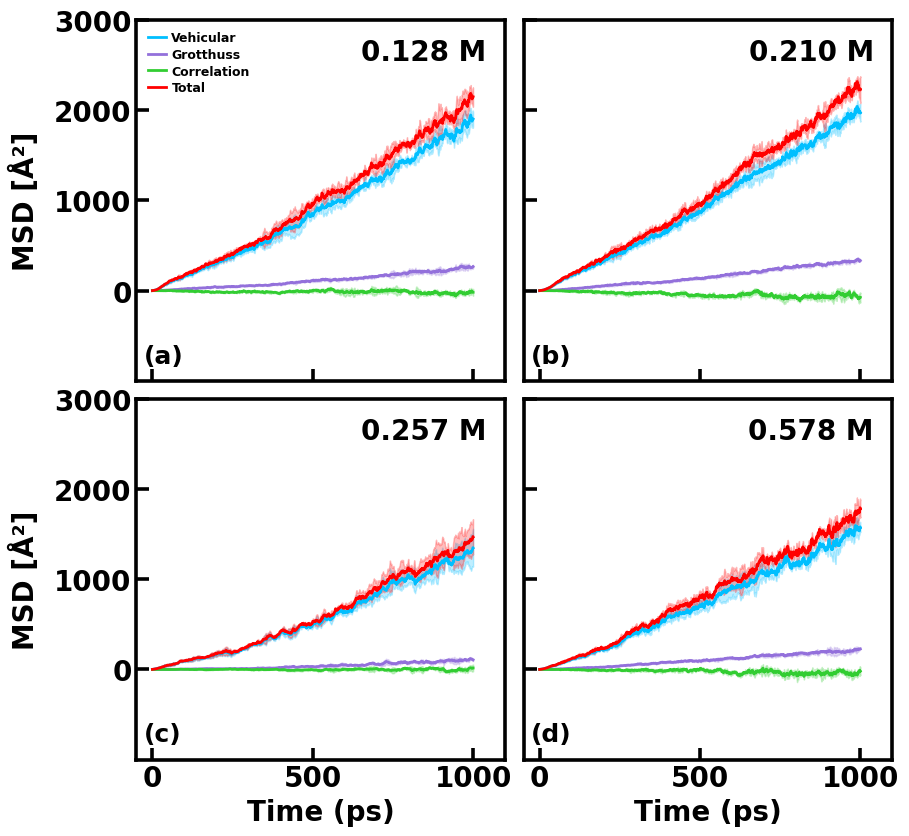

Saved: AllSystems_type10_ACS_panels.png
Saved: AllSystems_type10_ACS_panels.pdf


In [7]:
#!/usr/bin/env python3

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# -----------------------------
# USER SETTINGS
# -----------------------------
DT_FS = 1.0

FILES = {
    "0.128 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.128M/Reacter_3.0/A1_type10_replica_average_meanStd.csv",
    "0.210 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.210M/Reacter_3.0/A1_type10_replica_average_meanStd.csv",
    "0.257 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.257M/Reacter_3.0/A1_type10_replica_average_meanStd.csv",
    "0.578 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.578M/Reacter_3.0/A1_type10_replica_average_meanStd.csv",
}

OUT_PNG = "AllSystems_type10_ACS_panels.png"
OUT_PDF = "AllSystems_type10_ACS_panels.pdf"

# -----------------------------
# PLOT STYLE
# -----------------------------
LINE_W = 2
ALPHA = 0.25
AX_W = 2.6
TICK_W = 2.6
TICK_LEN = 9
SMOOTH = 15

COL_CONT  = "deepskyblue"
COL_DISC  = "mediumpurple"
COL_CORR  = "limegreen"
COL_TOTAL = "red"

YMIN = -1000
YMAX = 3000
XMIN = -50
XMAX = 1100

LABEL_SIZE  = 20
TICK_SIZE   = 20
TITLE_SIZE  = 20
PANEL_SIZE  = 18
LEGEND_SIZE = 9          # ← reduced; controls pt size in the SAVED file

# -----------------------------
# GLOBAL STYLE
# -----------------------------
mpl.rcParams.update({
    "font.family"      : "sans-serif",
    "font.weight"      : "bold",
    "axes.labelweight" : "bold",
    "axes.linewidth"   : AX_W,
    "xtick.direction"  : "in",
    "ytick.direction"  : "in",
})

# -----------------------------
# FUNCTIONS
# -----------------------------
def smooth(y, w):
    if w <= 1:
        return y
    return pd.Series(y).rolling(
        window=w,
        center=True,
        min_periods=max(2, w // 3)
    ).mean().to_numpy()


def load_csv(path):
    df = pd.read_csv(path)
    return pd.DataFrame({
        "time"     : df["time"],
        "cont_mean": df["cont_sq_mean"],
        "cont_std" : df["cont_sq_std"],
        "disc_mean": df["disc_sq_mean"],
        "disc_std" : df["disc_sq_std"],
        "corr_mean": df["corr_mean"],
        "corr_std" : df["corr_sq_std"] if "corr_sq_std" in df else df["corr_std"],
        "tot_mean" : df["total_mean"],
        "tot_std"  : df["total_std"],
    })


def style_ticklabels(ax):
    ax.tick_params(
        axis="both", which="major",
        labelsize=TICK_SIZE,
        width=TICK_W, length=TICK_LEN,
        top=False, right=False,
    )
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")


def plot_panel(ax, df, title, panel_label,
               xlabel=False, ylabel=False, legend=False):

    x = df["time"].values * DT_FS * 0.001   # fs → ps

    def draw(mean, std, color, label):
        m = smooth(mean, SMOOTH)
        s = smooth(std,  SMOOTH)
        ax.plot(x, m, lw=LINE_W, color=color, label=label)
        ax.fill_between(x, m - s, m + s, color=color, alpha=ALPHA)

    draw(df["cont_mean"], df["cont_std"], COL_CONT,  "Vehicular")
    draw(df["disc_mean"], df["disc_std"], COL_DISC,  "Grotthuss")
    draw(df["corr_mean"], df["corr_std"], COL_CORR,  "Correlation")
    draw(df["tot_mean"],  df["tot_std"],  COL_TOTAL, "Total")

    ax.set_xlim(XMIN, XMAX)
    ax.set_ylim(YMIN, YMAX)
    ax.set_xticks([0, 500, 1000])
    ax.set_yticks([0, 1000, 2000, 3000])
    ax.minorticks_off()

    style_ticklabels(ax)

    if xlabel:
        ax.set_xlabel("Time (ps)", fontsize=LABEL_SIZE)
    if ylabel:
        ax.set_ylabel("MSD [Å²]", fontsize=LABEL_SIZE, labelpad=10)

    # system title
    ax.text(
        0.95, 0.95, title,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=TITLE_SIZE, fontweight="bold",
    )

    # panel label
    ax.text(
        0.02, 0.05, panel_label,
        transform=ax.transAxes,
        fontsize=PANEL_SIZE, fontweight="bold",
    )

    if legend:
        ax.legend(
            loc="upper left",
            frameon=False,
            # size and weight both live inside prop — no separate fontsize arg
            prop={"size": LEGEND_SIZE, "weight": "bold"},
            handlelength=1.5,
            handletextpad=0.4,
            labelspacing=0.3,
        )


# -----------------------------
# MAIN
# -----------------------------
data = {k: load_csv(v) for k, v in FILES.items()}

fig, axes = plt.subplots(
    2, 2,
    figsize=(9, 8.5),
    sharex=True,
    sharey=True,
)

plot_panel(axes[0, 0], data["0.128 M"], "0.128 M", "(a)", xlabel=False, ylabel=True,  legend=True)
plot_panel(axes[0, 1], data["0.210 M"], "0.210 M", "(b)", xlabel=False, ylabel=False)
plot_panel(axes[1, 0], data["0.257 M"], "0.257 M", "(c)", xlabel=True,  ylabel=True)
plot_panel(axes[1, 1], data["0.578 M"], "0.578 M", "(d)", xlabel=True,  ylabel=False)

# top row: hide x tick labels
axes[0, 0].tick_params(labelbottom=False)
axes[0, 1].tick_params(labelbottom=False)

# right column: hide y tick labels
axes[0, 1].tick_params(labelleft=False)
axes[1, 1].tick_params(labelleft=False)

fig.subplots_adjust(
    left=0.14, right=0.98,
    bottom=0.11, top=0.98,
    wspace=0.05, hspace=0.05,
)

plt.savefig(OUT_PNG, dpi=600, bbox_inches="tight")
plt.savefig(OUT_PDF, dpi=600, bbox_inches="tight")
plt.show()

print("Saved:", OUT_PNG)
print("Saved:", OUT_PDF)

/scratch/local/31929966/ipykernel_1993195/4220512623.py:306: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: /blue/jsampath/avemula/Paper1_PE/Water/rdf_plots/rdf_2x2_concentration_pencil.png
Saved: /blue/jsampath/avemula/Paper1_PE/Water/rdf_plots/rdf_2x2_concentration_pencil.pdf


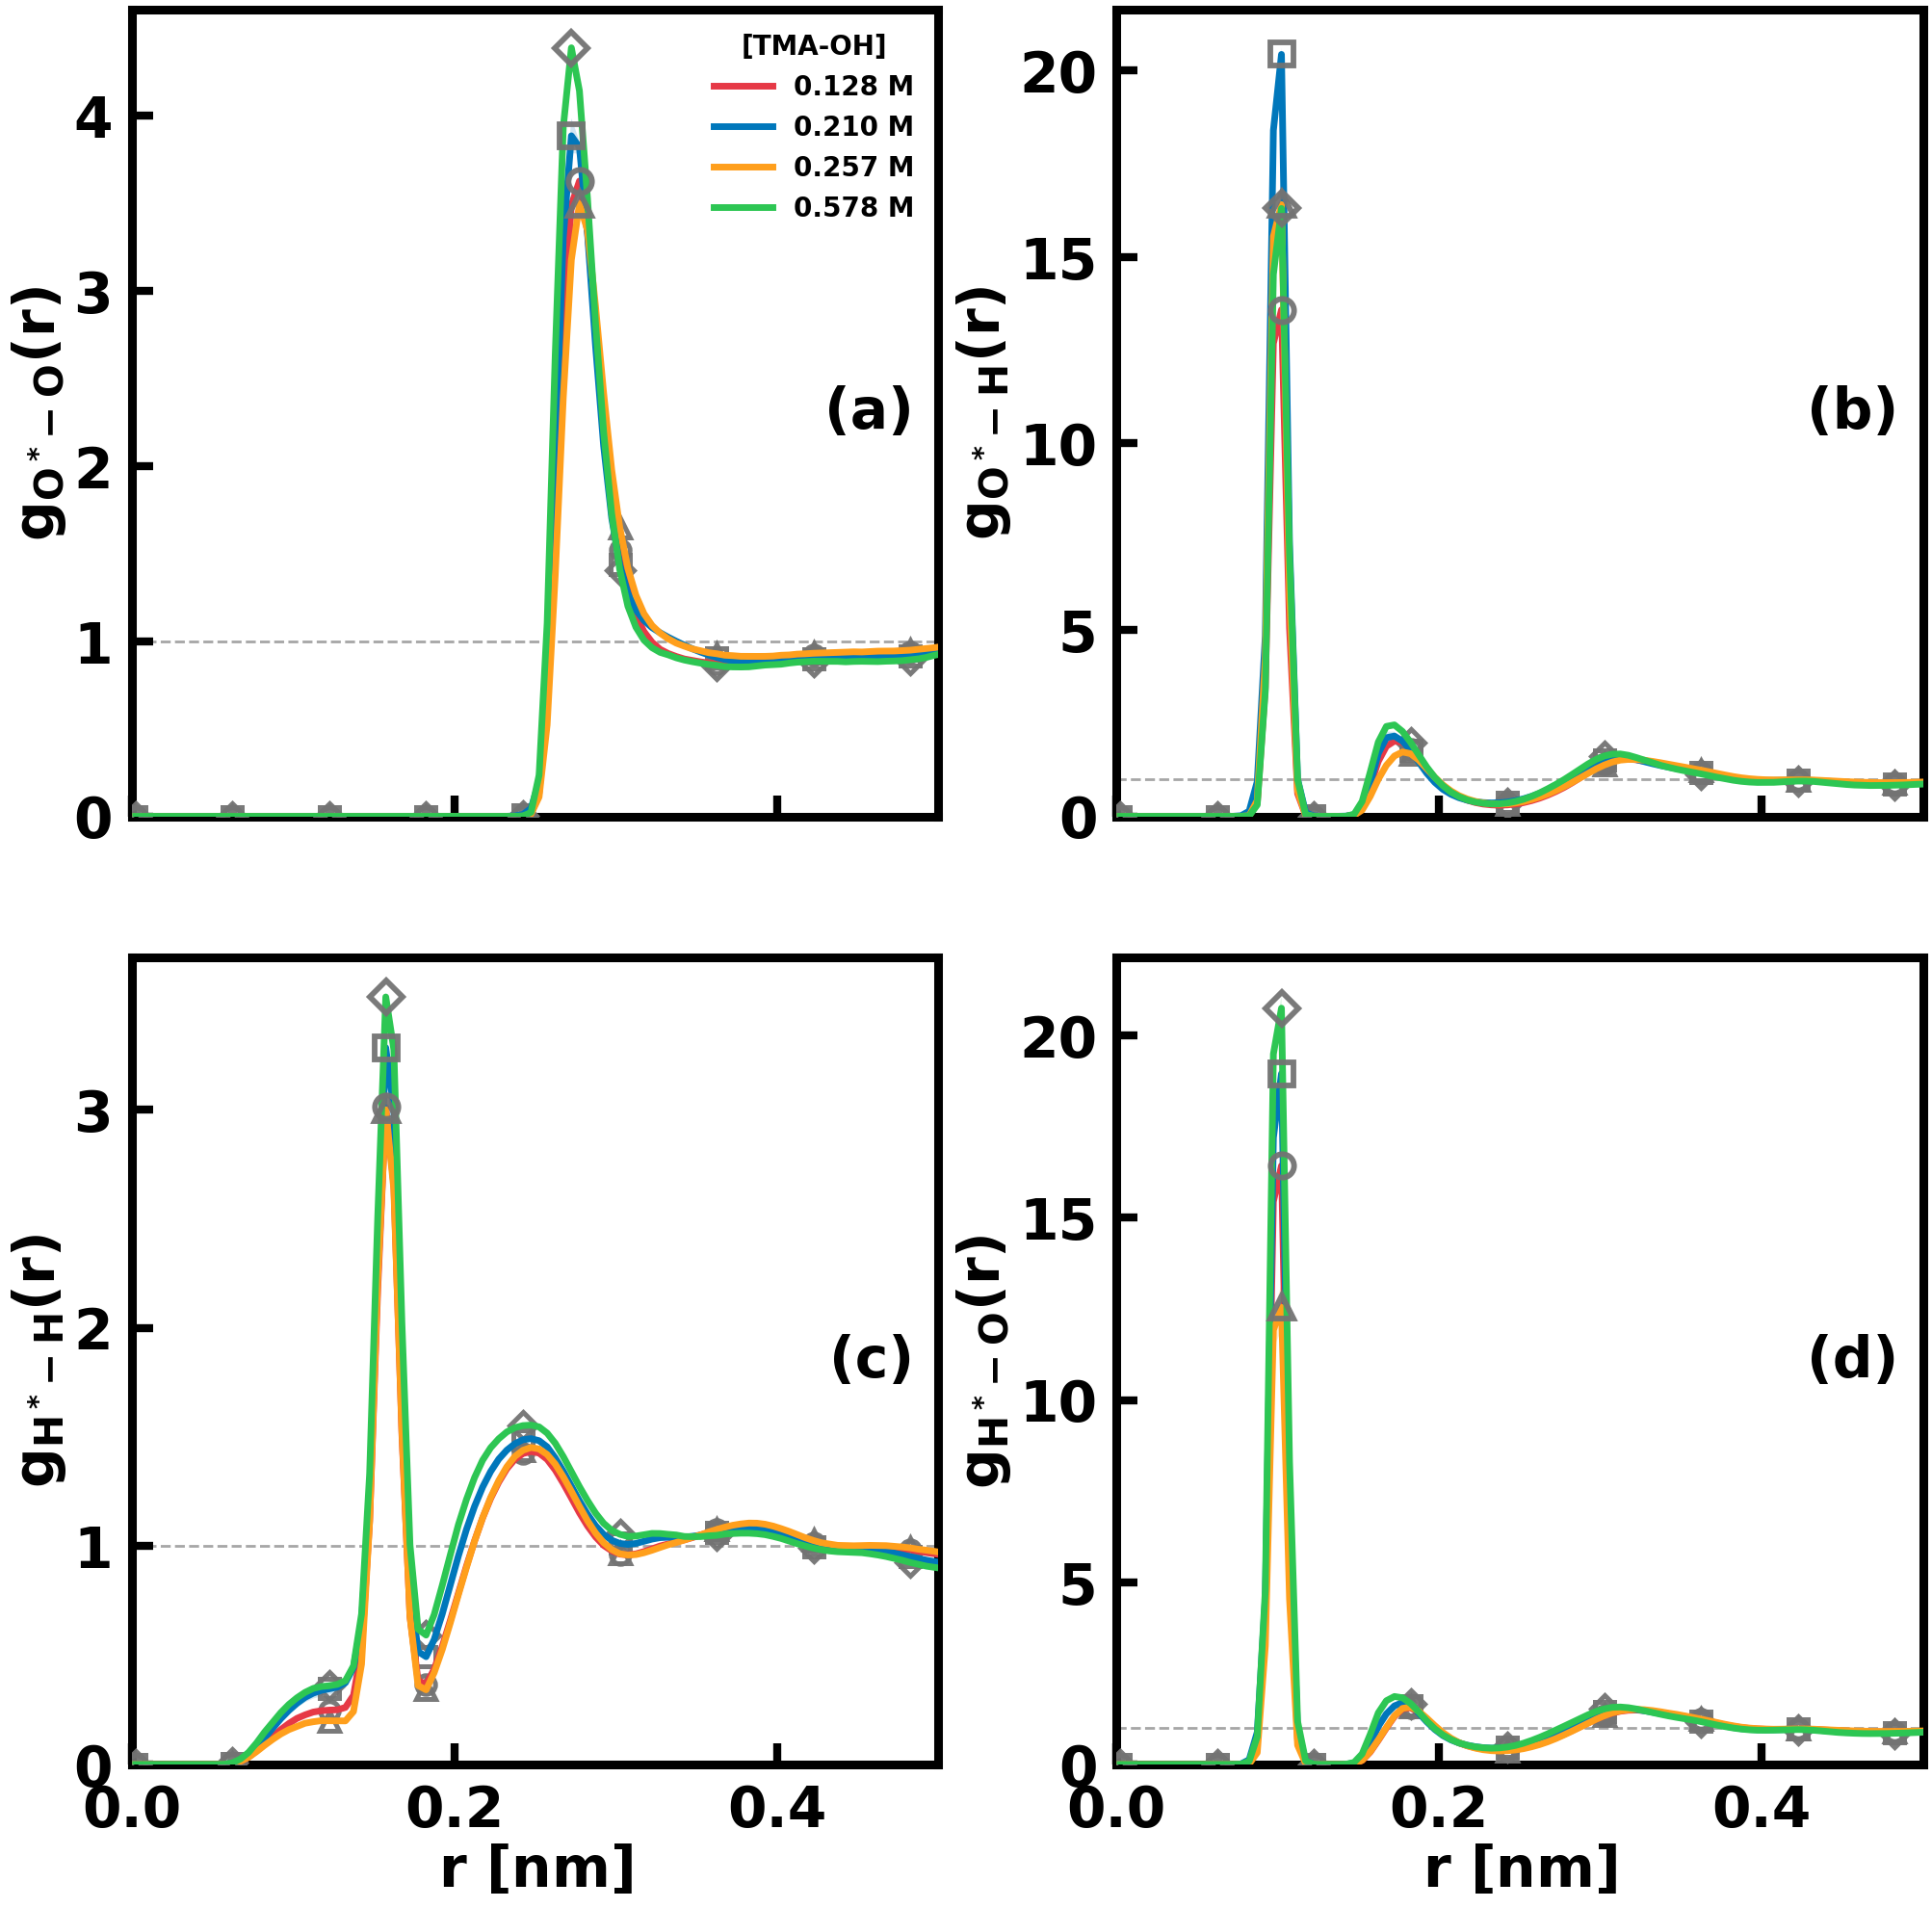

In [3]:
#!/usr/bin/env python3
"""
2x2 RDF panels — publication style
  - Pencil/sketch markers at first peak
  - Bold fonts, square panels, ticks inside (left + bottom only)
  - x-axis in nm, cut at 0.5 nm
  - Panel tags (a)-(d) at middle-right
  - Shaded ±1σ bands
  - 4 concentrations per panel

CSV columns required: r_Angstrom, g_mean, g_std
"""

import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════
#  INPUT PATHS
# ══════════════════════════════════════════════════════════

PANEL1_FILES = {
    "0.128 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.128M/O_O_mean_std_rdf.csv",
    "0.210 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.210M/Reacter_3.0/O_O_mean_std_rdf.csv",
    "0.257 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.257M/Reacter_3.0/O_O_mean_std_rdf.csv",
    "0.578 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.578M/O_O_mean_std_rdf.csv",
}
PANEL2_FILES = {
    "0.128 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.128M/O_H_mean_std_rdf.csv",
    "0.210 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.210M/Reacter_3.0/O_H_mean_std_rdf.csv",
    "0.257 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.257M/Reacter_3.0/O_H_mean_std_rdf.csv",
    "0.578 M":"/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.578M/O_H_mean_std_rdf.csv", 
}
PANEL3_FILES = {
    "0.128 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.128M/Reacter_3.0/rdf_OH_h_W_h/PE-P1_mean_std_rdf.csv",
    "0.210 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.210M/rdf_OH_h_W_h/PE-P1_mean_std_rdf.csv",
    "0.257 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.257M/rdf_OH_h_W_h/PE-P1_mean_std_rdf.csv",
    "0.578 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.578M/rdf_OH_h_W_h/PE-P1_mean_std_rdf.csv",
}
PANEL4_FILES = {
    "0.128 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.128M/PE-P1_mean_std_rdf.csv",
    "0.210 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.210M/Reacter_3.0/rdf_OH_h_W_O/PE-P1_mean_std_rdf.csv",
    "0.257 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.257M/Reacter_3.0/rdf_OH_h_W_O/PE-P1_mean_std_rdf.csv",
    "0.578 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.578M/Reacter_3.0/rdf_OH_h_W_O/PE-P1_mean_std_rdf.csv",
}

PANELS = [
    dict(tag="(a)", files=PANEL1_FILES, ylab=r"$g_{O^*\!-O}(r)$"),
    dict(tag="(b)", files=PANEL2_FILES, ylab=r"$g_{O^*\!-H}(r)$"),
    dict(tag="(c)", files=PANEL3_FILES, ylab=r"$g_{H^*\!-H}(r)$"),
    dict(tag="(d)", files=PANEL4_FILES, ylab=r"$g_{H^*\!-O}(r)$"),
]

# ══════════════════════════════════════════════════════════
#  OUTPUT
# ══════════════════════════════════════════════════════════

OUTDIR  = "/blue/jsampath/avemula/Paper1_PE/Water/rdf_plots"
OUTNAME = "rdf_2x2_concentration_pencil"

# ══════════════════════════════════════════════════════════
#  AXIS / WINDOW SETTINGS
# ══════════════════════════════════════════════════════════

XMAX_NM      = 0.5          # nm — x-axis cutoff
YMIN         = 0.0
YMAX         = None         # set e.g. 4.0 to fix all panels; None = auto
XLABEL       = r"$r$ [nm]"

PEAK_XMIN_NM = 0.10         # window to search for first peak marker
PEAK_XMAX_NM = 0.35

# ══════════════════════════════════════════════════════════
#  PER-CONCENTRATION STYLE
# ══════════════════════════════════════════════════════════

STYLE = {
    "0.128 M": dict(color="#E63946",  marker="o"),   # crimson red
    "0.210 M": dict(color="#0077BB",  marker="s"),   # deep blue
    "0.257 M": dict(color="#FF9F1C",  marker="^"),   # amber
    "0.578 M": dict(color="#2DC653",  marker="D"),   # emerald green
}

# ══════════════════════════════════════════════════════════
#  LINE / MARKER APPEARANCE
# ══════════════════════════════════════════════════════════

LINEWIDTH    = 5.0
MARK_EVERY   = 12           # show ghost marker every N points along curve
MS           = 14.0         # marker size
MEW          = 3.6          # marker edge width
MARKER_GREY  = "0.45"       # colour of all sketch markers

SHOW_STD_SHADE = True       # True → draw ±1σ shaded band
SHADE_ALPHA    = 0.18

# ══════════════════════════════════════════════════════════
#  PENCIL / SKETCH SETTINGS
# ══════════════════════════════════════════════════════════

SKETCH_SCALE       = 0.9
SKETCH_LENGTH      = 70.0
SKETCH_RANDOMNESS  = 2.5

# ══════════════════════════════════════════════════════════
#  FONTS & rcPARAMS
# ══════════════════════════════════════════════════════════

FONT_FAMILY  = "DejaVu Sans"
LABEL_SIZE   = 42
TICK_SIZE    = 42
LEGEND_SIZE  = 20

mpl.rcParams.update({
    "font.family":          FONT_FAMILY,
    "font.size":            TICK_SIZE,
    "font.weight":          "bold",
    "axes.labelsize":       LABEL_SIZE,
    "axes.labelweight":     "bold",
    "axes.titlesize":       LABEL_SIZE,
    "axes.linewidth":       6.5,
    "lines.linewidth":      LINEWIDTH,
    "legend.fontsize":      LEGEND_SIZE,
    "xtick.labelsize":      TICK_SIZE,
    "ytick.labelsize":      TICK_SIZE,
    "xtick.major.size":     16,
    "ytick.major.size":     16,
    "xtick.major.width":    6.0,
    "ytick.major.width":    6.0,
    "xtick.minor.size":     10,
    "ytick.minor.size":     10,
    "xtick.minor.width":    4.5,
    "ytick.minor.width":    4.5,
    "pdf.fonttype":         42,
    "ps.fonttype":          42,
    "savefig.dpi":          600,
    "mathtext.fontset":     "custom",
    "mathtext.rm":          "DejaVu Sans",
    "mathtext.it":          "DejaVu Sans:italic",
    "mathtext.bf":          "DejaVu Sans:bold",
    "mathtext.default":     "regular",
})


# ══════════════════════════════════════════════════════════
#  HELPERS
# ══════════════════════════════════════════════════════════

def load_csv(path: str):
    """Return (r_nm, g_mean, g_std) arrays from a CSV file."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file:\n  {path}")
    data = np.genfromtxt(path, delimiter=",", names=True)
    cols = set(data.dtype.names or [])
    missing = {"r_Angstrom", "g_mean", "g_std"} - cols
    if missing:
        raise ValueError(f"{path}\n  Missing columns: {missing}")
    r_nm   = np.asarray(data["r_Angstrom"], float) / 10.0   # Å → nm
    g_mean = np.asarray(data["g_mean"],     float)
    g_std  = np.asarray(data["g_std"],      float)
    return r_nm, g_mean, g_std


def first_peak(x, y, xmin, xmax):
    """(x, y) of the highest point inside [xmin, xmax], or None."""
    mask = (x >= xmin) & (x <= xmax)
    if not np.any(mask):
        return None
    idxs   = np.where(mask)[0]
    i_peak = idxs[np.argmax(y[mask])]
    return x[i_peak], y[i_peak]


def bold_ticklabels(ax):
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight("bold")
        lbl.set_fontfamily(FONT_FAMILY)


def format_ax(ax, ylab: str, add_xlabel: bool):
    """Apply publication-style formatting to a single axes."""
    for sp in ax.spines.values():
        sp.set_linewidth(mpl.rcParams["axes.linewidth"])

    # ticks inside, only left + bottom
    ax.tick_params(
        axis="both", which="both",
        direction="in",
        top=False, right=False,
        bottom=True, left=True,
        pad=14,
    )

    ax.set_xlim(0, XMAX_NM)
    ax.set_ylim(bottom=YMIN, top=YMAX)

    ax.set_ylabel(ylab, fontweight="bold")
    if add_xlabel:
        ax.set_xlabel(XLABEL, fontweight="bold")

    ax.set_box_aspect(1)   # square panel
    bold_ticklabels(ax)


def add_sketch_marker(ax, x, y, marker, peak=False):
    """Plot a pencil-sketch marker (ghost along curve or at peak)."""
    scale  = MS * (1.25 if peak else 1.0)
    width  = MEW + (0.6 if peak else 0.0)
    artist, = ax.plot(
        x, y,
        linestyle="None",
        marker=marker,
        markersize=scale,
        markerfacecolor="none",
        markeredgecolor=MARKER_GREY,
        markeredgewidth=width,
        zorder=10 if peak else 4,
        alpha=0.95,
    )
    artist.set_sketch_params(
        scale=SKETCH_SCALE,
        length=SKETCH_LENGTH,
        randomness=SKETCH_RANDOMNESS,
    )
    return artist


# ══════════════════════════════════════════════════════════
#  MAIN
# ══════════════════════════════════════════════════════════

def main():
    os.makedirs(OUTDIR, exist_ok=True)

    fig, axes = plt.subplots(
        2, 2,
        figsize=(24, 24),
        sharex=True,
        gridspec_kw={"hspace": 0.14, "wspace": 0.22},
    )
    axes = axes.flatten()

    for i, (ax, panel) in enumerate(zip(axes, PANELS)):

        for label, path in panel["files"].items():
            r_nm, g_mean, g_std = load_csv(path)
            st = STYLE[label]

            # ── solid coloured line ──────────────────────────
            ax.plot(r_nm, g_mean,
                    color=st["color"],
                    lw=LINEWIDTH,
                    label=label if i == 0 else None,
                    zorder=5)

            # ── ±1σ shaded band ─────────────────────────────
            if SHOW_STD_SHADE and np.any(g_std > 0):
                ax.fill_between(
                    r_nm,
                    g_mean - g_std,
                    g_mean + g_std,
                    color=st["color"],
                    alpha=SHADE_ALPHA,
                    linewidth=0,
                    zorder=3,
                )

            # ── ghost markers along curve ────────────────────
            xs_ghost = r_nm[::MARK_EVERY]
            ys_ghost = g_mean[::MARK_EVERY]
            add_sketch_marker(ax, xs_ghost, ys_ghost, st["marker"], peak=False)

            # ── explicit sketch marker at first peak ─────────
            pk = first_peak(r_nm, g_mean, PEAK_XMIN_NM, PEAK_XMAX_NM)
            if pk is not None:
                add_sketch_marker(ax, [pk[0]], [pk[1]], st["marker"], peak=True)

        # ── panel tag at middle-right ────────────────────────
        ax.text(
            0.97, 0.50, panel["tag"],
            transform=ax.transAxes,
            fontsize=LABEL_SIZE,
            fontweight="bold",
            ha="right", va="center",
        )

        # ── reference line at g = 1 ──────────────────────────
        ax.axhline(1.0, color="0.65", lw=2.0, ls="--", zorder=1)

        format_ax(ax, panel["ylab"], add_xlabel=(i >= 2))

    # ── shared legend on panel (a) ───────────────────────────
    leg = axes[0].legend(
        frameon=False,
        loc="upper right",
        handlelength=2.2,
        borderaxespad=0.5,
        title="[TMA-OH]",
        title_fontsize=LEGEND_SIZE,
    )
    for t in leg.get_texts():
        t.set_fontweight("bold")
        t.set_fontfamily(FONT_FAMILY)

    fig.tight_layout()

    for ext in ("png", "pdf"):
        fout = os.path.join(OUTDIR, f"{OUTNAME}.{ext}")
        fig.savefig(fout, bbox_inches="tight")
        print("Saved:", fout)


if __name__ == "__main__":
    main()

/scratch/local/31929966/ipykernel_1993195/2769942078.py:303: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: /blue/jsampath/avemula/Paper1_PE/Water/rdf_plots/rdf_2x2_concentration_pencil_new.png
Saved: /blue/jsampath/avemula/Paper1_PE/Water/rdf_plots/rdf_2x2_concentration_pencil_new.pdf


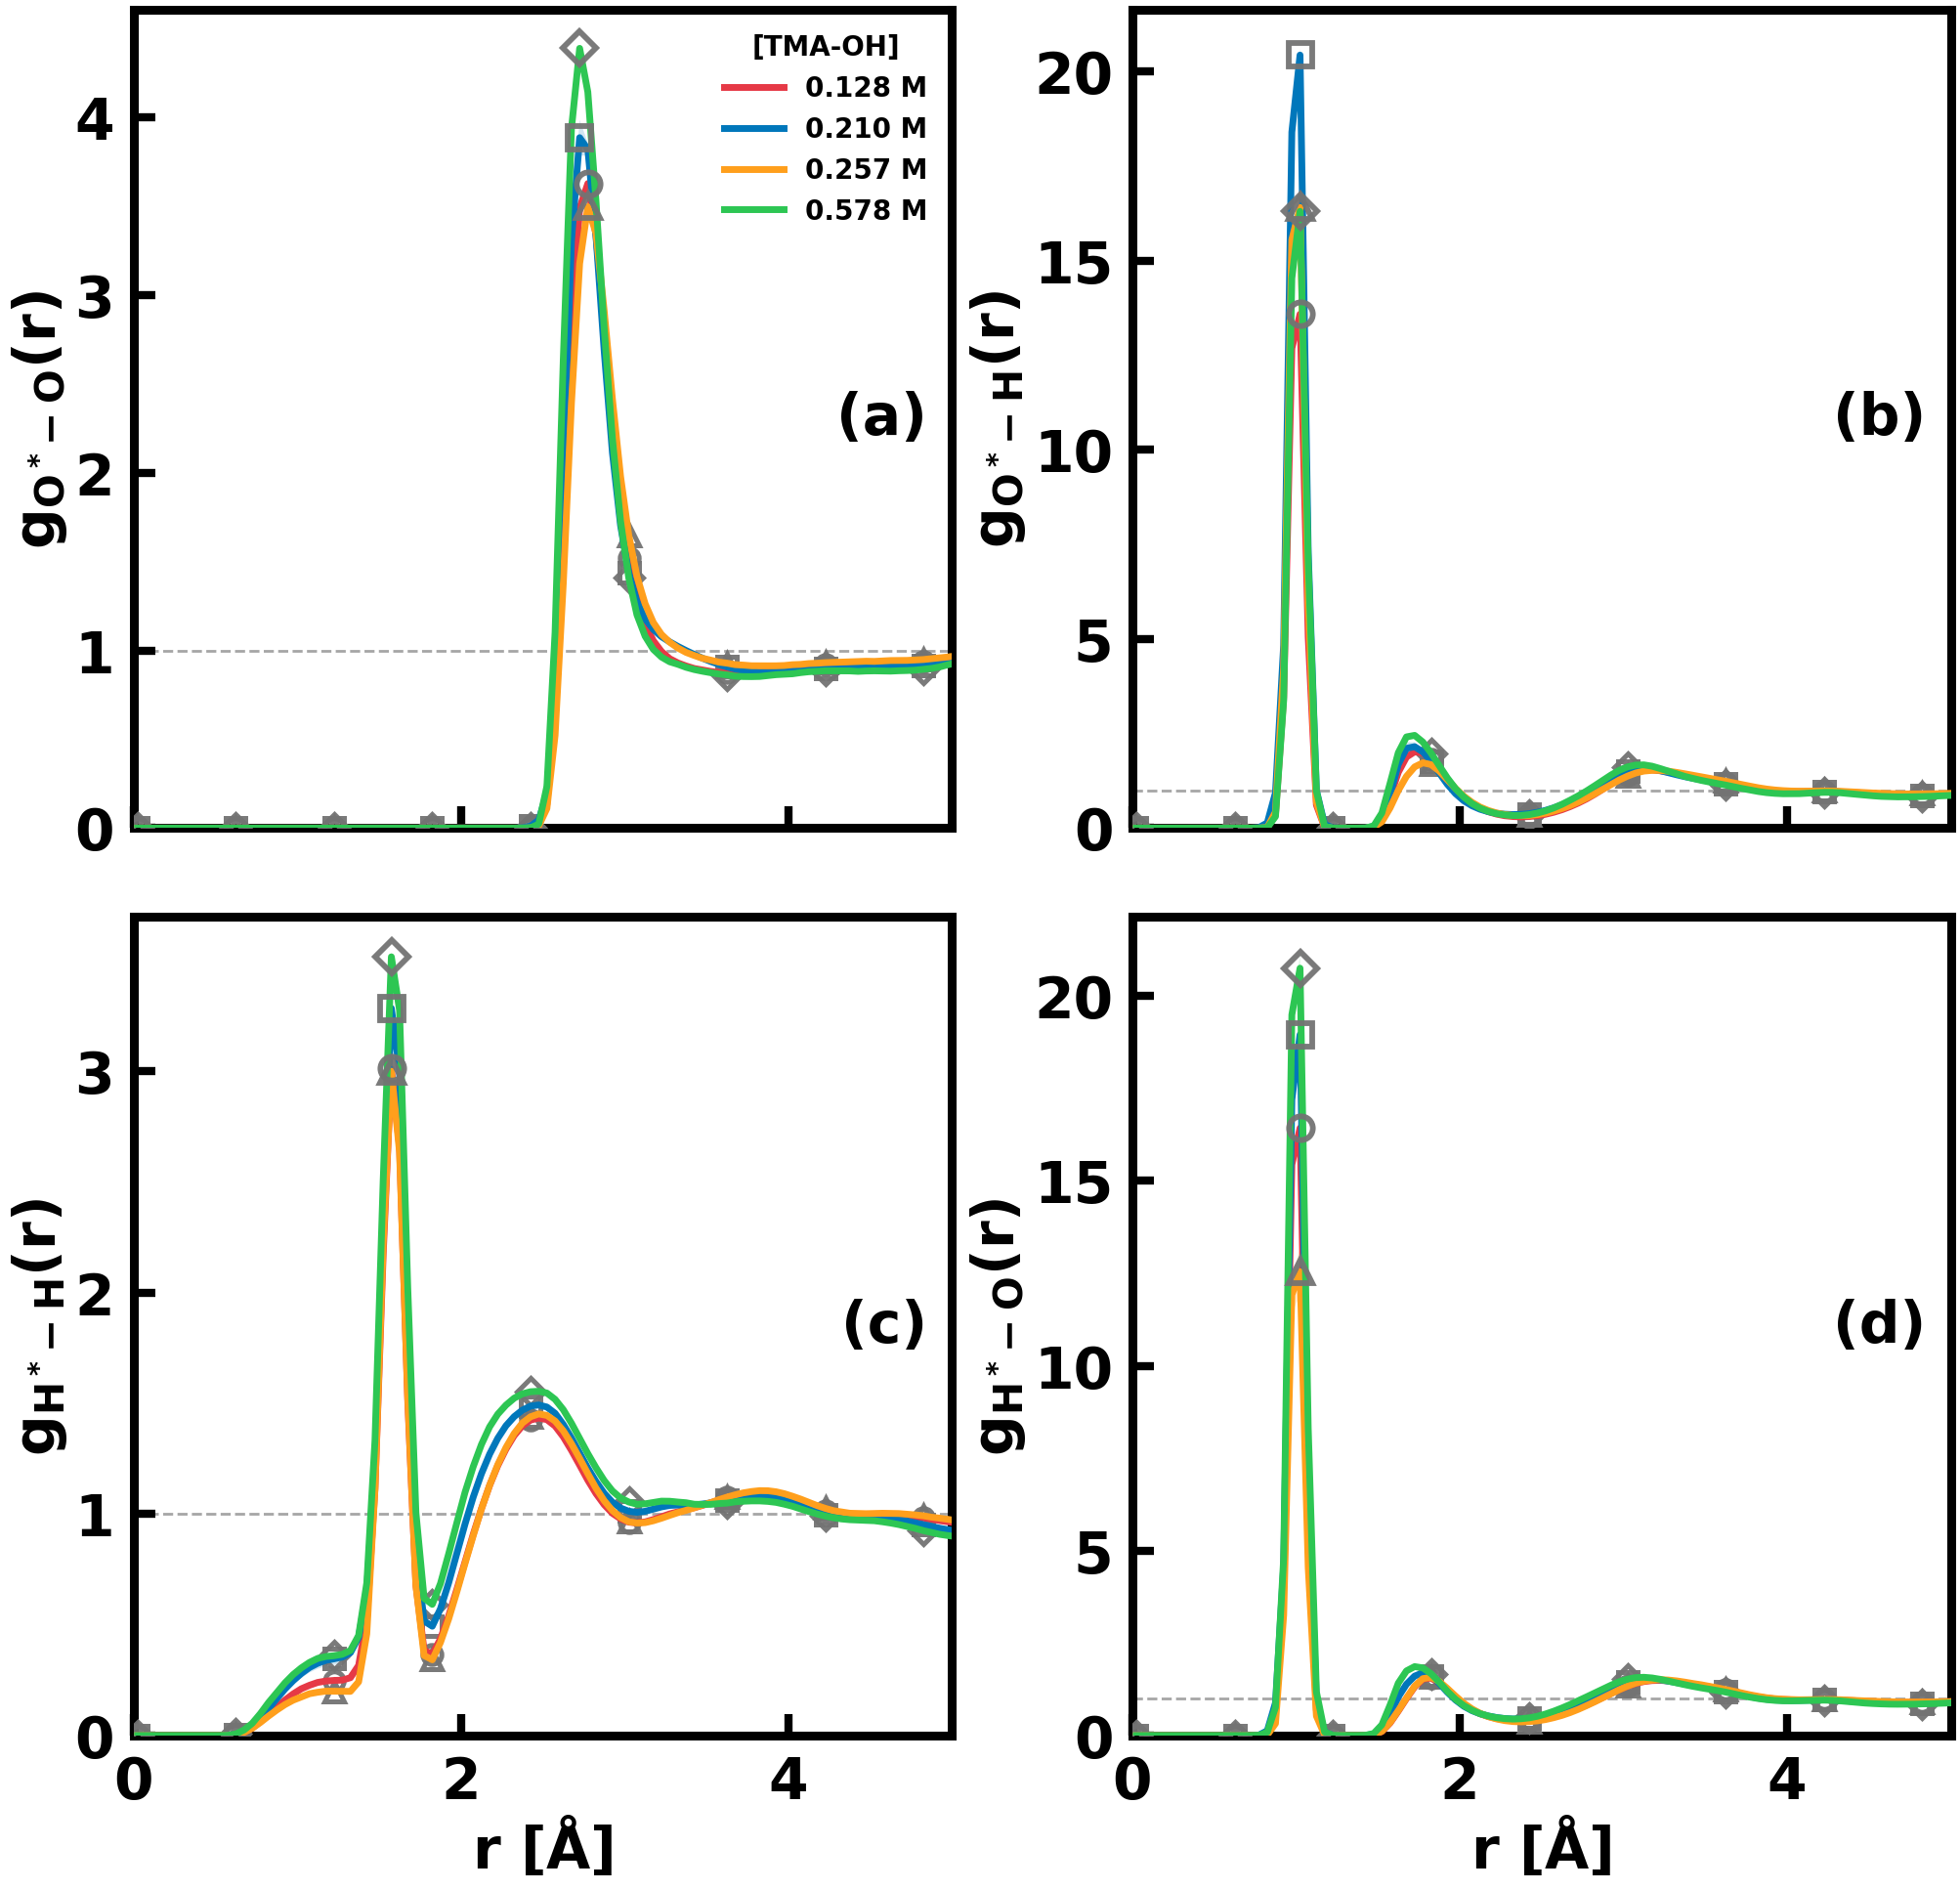

In [4]:
#!/usr/bin/env python3
"""
2x2 RDF panels — publication style
  - Pencil/sketch markers at first peak
  - Bold fonts, square panels, ticks inside (left + bottom only)
  - x-axis in Angstroms
  - Panel tags (a)-(d) at middle-right
  - Shaded ±1σ bands
  - 4 concentrations per panel

CSV columns required: r_Angstrom, g_mean, g_std
"""

import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════
#  INPUT PATHS
# ══════════════════════════════════════════════════════════

PANEL1_FILES = {
    "0.128 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.128M/O_O_mean_std_rdf.csv",
    "0.210 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.210M/Reacter_3.0/O_O_mean_std_rdf.csv",
    "0.257 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.257M/Reacter_3.0/O_O_mean_std_rdf.csv",
    "0.578 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.578M/O_O_mean_std_rdf.csv",
}
PANEL2_FILES = {
    "0.128 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.128M/O_H_mean_std_rdf.csv",
    "0.210 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.210M/Reacter_3.0/O_H_mean_std_rdf.csv",
    "0.257 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.257M/Reacter_3.0/O_H_mean_std_rdf.csv",
    "0.578 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.578M/O_H_mean_std_rdf.csv",
}
PANEL3_FILES = {
    "0.128 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.128M/Reacter_3.0/rdf_OH_h_W_h/PE-P1_mean_std_rdf.csv",
    "0.210 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.210M/rdf_OH_h_W_h/PE-P1_mean_std_rdf.csv",
    "0.257 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.257M/rdf_OH_h_W_h/PE-P1_mean_std_rdf.csv",
    "0.578 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.578M/rdf_OH_h_W_h/PE-P1_mean_std_rdf.csv",
}
PANEL4_FILES = {
    "0.128 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.128M/PE-P1_mean_std_rdf.csv",
    "0.210 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.210M/Reacter_3.0/rdf_OH_h_W_O/PE-P1_mean_std_rdf.csv",
    "0.257 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.257M/Reacter_3.0/rdf_OH_h_W_O/PE-P1_mean_std_rdf.csv",
    "0.578 M": "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water/0.578M/Reacter_3.0/rdf_OH_h_W_O/PE-P1_mean_std_rdf.csv",
}

PANELS = [
    dict(tag="(a)", files=PANEL1_FILES, ylab=r"$g_{O^*\!-O}(r)$"),
    dict(tag="(b)", files=PANEL2_FILES, ylab=r"$g_{O^*\!-H}(r)$"),
    dict(tag="(c)", files=PANEL3_FILES, ylab=r"$g_{H^*\!-H}(r)$"),
    dict(tag="(d)", files=PANEL4_FILES, ylab=r"$g_{H^*\!-O}(r)$"),
]

# ══════════════════════════════════════════════════════════
#  OUTPUT
# ══════════════════════════════════════════════════════════

OUTDIR  = "/blue/jsampath/avemula/Paper1_PE/Water/rdf_plots"
OUTNAME = "rdf_2x2_concentration_pencil_new"

# ══════════════════════════════════════════════════════════
#  AXIS / WINDOW SETTINGS  (all in Å)
# ══════════════════════════════════════════════════════════

XMAX         = 5.0          # Å — x-axis cutoff
YMIN         = 0.0
YMAX         = None         # set e.g. 4.0 to fix all panels; None = auto
XLABEL       = r"$r$ [Å]"

PEAK_XMIN    = 1.0          # Å — window to search for first peak marker
PEAK_XMAX    = 3.5          # Å

# ══════════════════════════════════════════════════════════
#  PER-CONCENTRATION STYLE
# ══════════════════════════════════════════════════════════

STYLE = {
    "0.128 M": dict(color="#E63946",  marker="o"),   # crimson red
    "0.210 M": dict(color="#0077BB",  marker="s"),   # deep blue
    "0.257 M": dict(color="#FF9F1C",  marker="^"),   # amber
    "0.578 M": dict(color="#2DC653",  marker="D"),   # emerald green
}
# ══════════════════════════════════════════════════════════
#  LINE / MARKER APPEARANCE
# ══════════════════════════════════════════════════════════

LINEWIDTH      = 5.0
MARK_EVERY     = 12         # show ghost marker every N points along curve
MS             = 14.0       # marker size
MEW            = 3.6        # marker edge width
MARKER_GREY    = "0.45"     # colour of all sketch markers

SHOW_STD_SHADE = True       # True → draw ±1σ shaded band
SHADE_ALPHA    = 0.18

# ══════════════════════════════════════════════════════════
#  PENCIL / SKETCH SETTINGS
# ══════════════════════════════════════════════════════════

SKETCH_SCALE      = 0.9
SKETCH_LENGTH     = 70.0
SKETCH_RANDOMNESS = 2.5

# ══════════════════════════════════════════════════════════
#  FONTS & rcPARAMS
# ══════════════════════════════════════════════════════════

FONT_FAMILY  = "DejaVu Sans"
LABEL_SIZE   = 42
TICK_SIZE    = 42
LEGEND_SIZE  = 20

mpl.rcParams.update({
    "font.family":       FONT_FAMILY,
    "font.size":         TICK_SIZE,
    "font.weight":       "bold",
    "axes.labelsize":    LABEL_SIZE,
    "axes.labelweight":  "bold",
    "axes.titlesize":    LABEL_SIZE,
    "axes.linewidth":    6.5,
    "lines.linewidth":   LINEWIDTH,
    "legend.fontsize":   LEGEND_SIZE,
    "xtick.labelsize":   TICK_SIZE,
    "ytick.labelsize":   TICK_SIZE,
    "xtick.major.size":  16,
    "ytick.major.size":  16,
    "xtick.major.width": 6.0,
    "ytick.major.width": 6.0,
    "xtick.minor.size":  10,
    "ytick.minor.size":  10,
    "xtick.minor.width": 4.5,
    "ytick.minor.width": 4.5,
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
    "savefig.dpi":       600,
    "mathtext.fontset":  "custom",
    "mathtext.rm":       "DejaVu Sans",
    "mathtext.it":       "DejaVu Sans:italic",
    "mathtext.bf":       "DejaVu Sans:bold",
    "mathtext.default":  "regular",
})

# ══════════════════════════════════════════════════════════
#  HELPERS
# ══════════════════════════════════════════════════════════

def load_csv(path: str):
    """Return (r_ang, g_mean, g_std) arrays from a CSV file."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file:\n  {path}")
    data = np.genfromtxt(path, delimiter=",", names=True)
    cols = set(data.dtype.names or [])
    missing = {"r_Angstrom", "g_mean", "g_std"} - cols
    if missing:
        raise ValueError(f"{path}\n  Missing columns: {missing}")
    r_ang  = np.asarray(data["r_Angstrom"], float)   # already in Å — no conversion
    g_mean = np.asarray(data["g_mean"],     float)
    g_std  = np.asarray(data["g_std"],      float)
    return r_ang, g_mean, g_std


def first_peak(x, y, xmin, xmax):
    """(x, y) of the highest point inside [xmin, xmax], or None."""
    mask = (x >= xmin) & (x <= xmax)
    if not np.any(mask):
        return None
    idxs   = np.where(mask)[0]
    i_peak = idxs[np.argmax(y[mask])]
    return x[i_peak], y[i_peak]


def bold_ticklabels(ax):
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight("bold")
        lbl.set_fontfamily(FONT_FAMILY)


def format_ax(ax, ylab: str, add_xlabel: bool):
    """Apply publication-style formatting to a single axes."""
    for sp in ax.spines.values():
        sp.set_linewidth(mpl.rcParams["axes.linewidth"])

    ax.tick_params(
        axis="both", which="both",
        direction="in",
        top=False, right=False,
        bottom=True, left=True,
        pad=14,
    )

    ax.set_xlim(0, XMAX)
    ax.set_ylim(bottom=YMIN, top=YMAX)

    ax.set_ylabel(ylab, fontweight="bold")
    if add_xlabel:
        ax.set_xlabel(XLABEL, fontweight="bold")

    ax.set_box_aspect(1)
    bold_ticklabels(ax)


def add_sketch_marker(ax, x, y, marker, peak=False):
    """Plot a pencil-sketch marker (ghost along curve or at peak)."""
    scale  = MS * (1.25 if peak else 1.0)
    width  = MEW + (0.6 if peak else 0.0)
    artist, = ax.plot(
        x, y,
        linestyle="None",
        marker=marker,
        markersize=scale,
        markerfacecolor="none",
        markeredgecolor=MARKER_GREY,
        markeredgewidth=width,
        zorder=10 if peak else 4,
        alpha=0.95,
    )
    artist.set_sketch_params(
        scale=SKETCH_SCALE,
        length=SKETCH_LENGTH,
        randomness=SKETCH_RANDOMNESS,
    )
    return artist


# ══════════════════════════════════════════════════════════
#  MAIN
# ══════════════════════════════════════════════════════════

def main():
    os.makedirs(OUTDIR, exist_ok=True)

    fig, axes = plt.subplots(
        2, 2,
        figsize=(24, 24),
        sharex=True,
        gridspec_kw={"hspace": 0.01, "wspace": 0.22},
    )
    axes = axes.flatten()

    for i, (ax, panel) in enumerate(zip(axes, PANELS)):

        for label, path in panel["files"].items():
            r_ang, g_mean, g_std = load_csv(path)
            st = STYLE[label]

            # ── solid coloured line ──────────────────────────
            ax.plot(r_ang, g_mean,
                    color=st["color"],
                    lw=LINEWIDTH,
                    label=label if i == 0 else None,
                    zorder=5)

            # ── ±1σ shaded band ─────────────────────────────
            if SHOW_STD_SHADE and np.any(g_std > 0):
                ax.fill_between(
                    r_ang,
                    g_mean - g_std,
                    g_mean + g_std,
                    color=st["color"],
                    alpha=SHADE_ALPHA,
                    linewidth=0,
                    zorder=3,
                )

            # ── ghost markers along curve ────────────────────
            xs_ghost = r_ang[::MARK_EVERY]
            ys_ghost = g_mean[::MARK_EVERY]
            add_sketch_marker(ax, xs_ghost, ys_ghost, st["marker"], peak=False)

            # ── explicit sketch marker at first peak ─────────
            pk = first_peak(r_ang, g_mean, PEAK_XMIN, PEAK_XMAX)
            if pk is not None:
                add_sketch_marker(ax, [pk[0]], [pk[1]], st["marker"], peak=True)

        # ── panel tag at middle-right ────────────────────────
        ax.text(
            0.97, 0.50, panel["tag"],
            transform=ax.transAxes,
            fontsize=LABEL_SIZE,
            fontweight="bold",
            ha="right", va="center",
        )

        # ── reference line at g = 1 ──────────────────────────
        ax.axhline(1.0, color="0.65", lw=2.0, ls="--", zorder=1)

        format_ax(ax, panel["ylab"], add_xlabel=(i >= 2))

    # ── shared legend on panel (a) ───────────────────────────
    leg = axes[0].legend(
        frameon=False,
        loc="upper right",
        handlelength=2.2,
        borderaxespad=0.5,
        title="[TMA-OH]",
        title_fontsize=LEGEND_SIZE,
    )
    for t in leg.get_texts():
        t.set_fontweight("bold")
        t.set_fontfamily(FONT_FAMILY)

    fig.tight_layout()

    for ext in ("png", "pdf"):
        fout = os.path.join(OUTDIR, f"{OUTNAME}.{ext}")
        fig.savefig(fout, bbox_inches="tight")
        print("Saved:", fout)


if __name__ == "__main__":
    main()